<a href="https://colab.research.google.com/github/ElMad6261/spotify-music-analysis/blob/main/03_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup
**texto en negrita**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="darkgrid")

df = pd.read_csv('/content/drive/MyDrive/spotify-analysis/data/processed/dataset_clean.csv')
print("Shape:", df.shape)

Mounted at /content/drive
Shape: (113999, 22)


**Seleccionar y normalizar**

In [2]:
features = ['danceability', 'energy', 'loudness', 'tempo',
            'valence', 'acousticness', 'speechiness', 'instrumentalness']

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features normalizadas:", X_scaled.shape)

Features normalizadas: (113999, 8)


**Encontrar número óptimo de clusters (Elbow Method)**

k=2 — Inertia: 692686 | Silhouette: 0.288
k=3 — Inertia: 603300 | Silhouette: 0.181
k=4 — Inertia: 538564 | Silhouette: 0.192
k=5 — Inertia: 476343 | Silhouette: 0.199
k=6 — Inertia: 425417 | Silhouette: 0.212
k=7 — Inertia: 396691 | Silhouette: 0.190
k=8 — Inertia: 373174 | Silhouette: 0.199
k=9 — Inertia: 354393 | Silhouette: 0.184
k=10 — Inertia: 339813 | Silhouette: 0.172


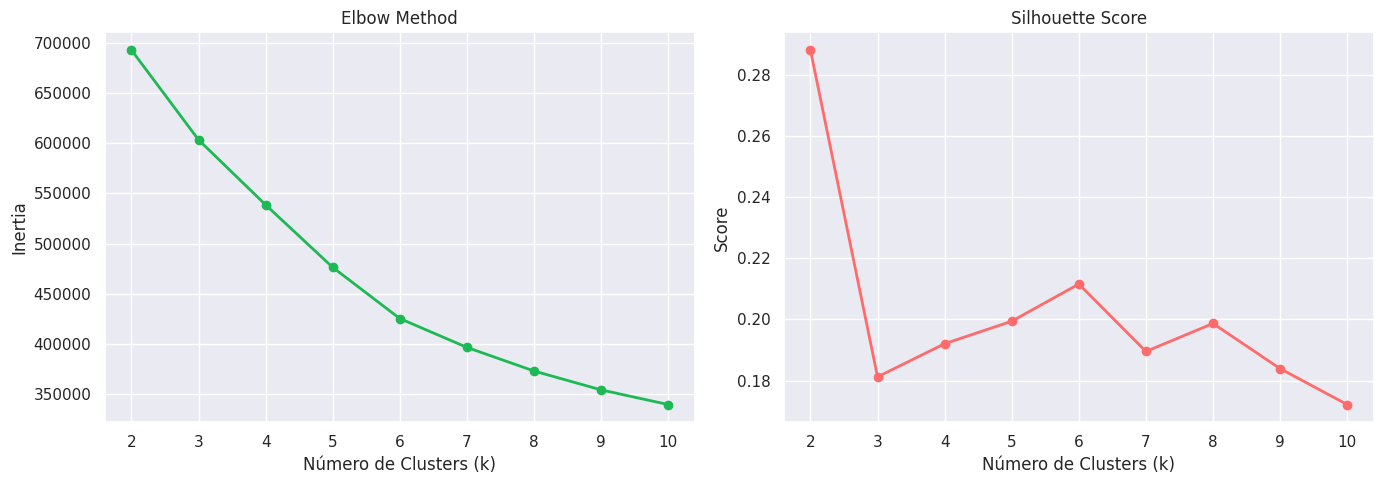

In [3]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=10000))
    print(f"k={k} — Inertia: {km.inertia_:.0f} | Silhouette: {silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='#1DB954', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='#FF6B6B', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/elbow_silhouette.png', dpi=150)
plt.show()

**Entrenar modelo final**

In [4]:
# Elige k según el elbow — normalmente 5 o 6 funciona bien con este dataset
OPTIMAL_K = 6

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Distribución de clusters:")
print(df['cluster'].value_counts().sort_index())

Distribución de clusters:
cluster
0     4525
1    28462
2    23925
3    12057
4    37514
5     7516
Name: count, dtype: int64


 **Visualizar clusters con PCA**

Varianza explicada: 53.4%


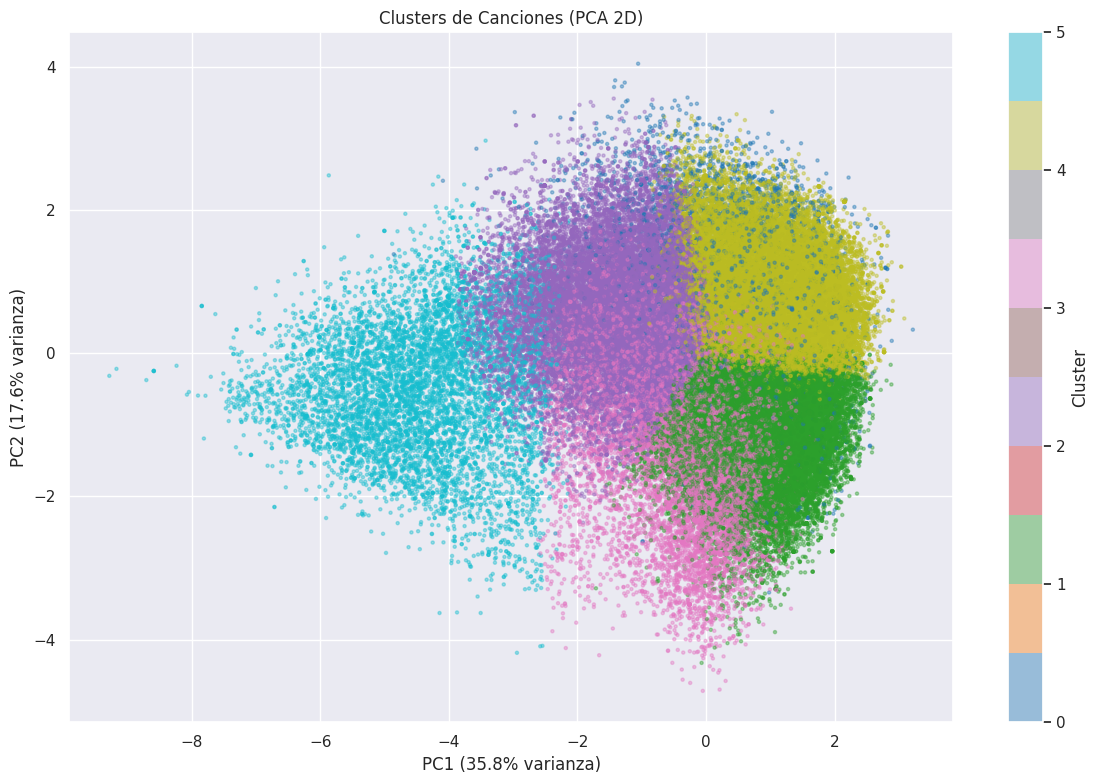

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['cluster'], cmap='tab10',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters de Canciones (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/clusters_pca.png', dpi=150)
plt.show()

**Perfil de cada cluster**

         danceability  energy  loudness    tempo  valence  acousticness  \
cluster                                                                   
0               0.652   0.656    -8.314  118.224    0.510         0.406   
1               0.469   0.815    -5.395  139.166    0.371         0.077   
2               0.527   0.383   -10.581  113.095    0.395         0.675   
3               0.582   0.746    -8.385  126.884    0.338         0.110   
4               0.696   0.732    -6.321  117.818    0.700         0.211   
5               0.346   0.176   -21.151  102.893    0.184         0.862   

         speechiness  instrumentalness  
cluster                                 
0              0.482             0.026  
1              0.079             0.032  
2              0.049             0.028  
3              0.070             0.788  
4              0.076             0.019  
5              0.050             0.785  


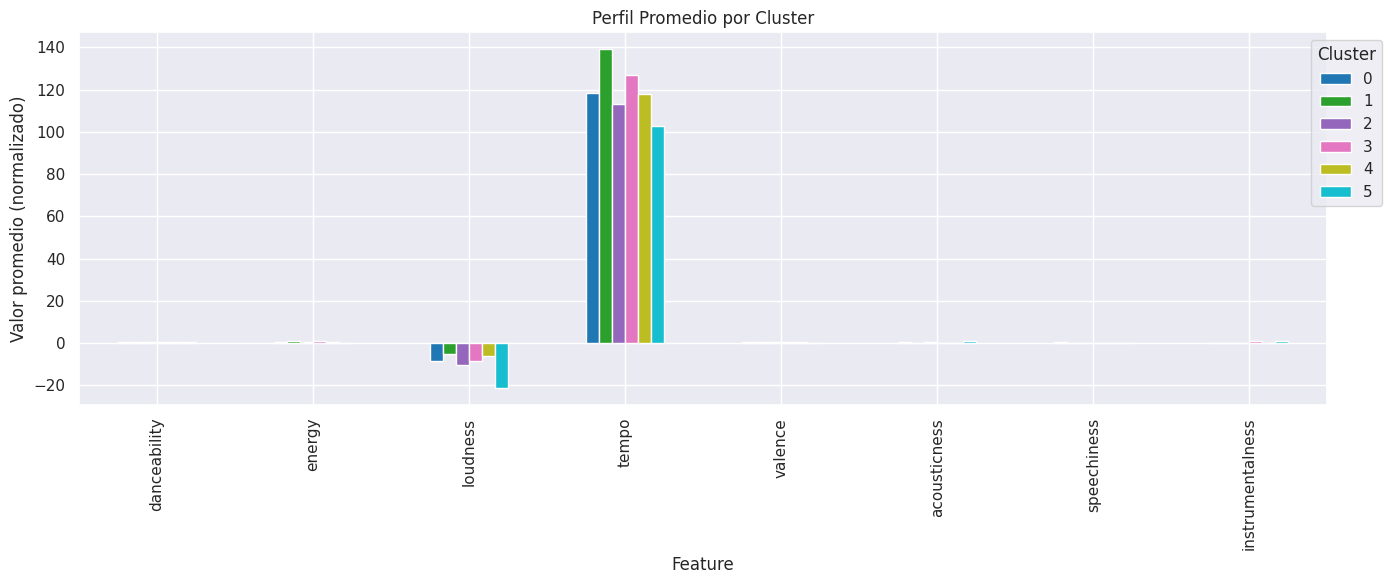

In [6]:
cluster_profile = df.groupby('cluster')[features].mean().round(3)
print(cluster_profile)

cluster_profile.T.plot(kind='bar', figsize=(14, 6), colormap='tab10')
plt.title('Perfil Promedio por Cluster')
plt.xlabel('Feature')
plt.ylabel('Valor promedio (normalizado)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/cluster_profiles.png', dpi=150)
plt.show()

**Guardar dataset con clusters**

In [8]:
cluster_names = {
    0: 'Hip-Hop / Rap',
    1: 'Hard Rock / Metal',
    2: 'Acoustic / Folk',
    3: 'Electronic Instrumental',
    4: 'Pop / Dance',
    5: 'Classical / Ambient'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

# Verificar distribución
print(df['cluster_name'].value_counts())

# Guardar
df.to_csv('/content/drive/MyDrive/spotify-analysis/data/processed/dataset_clustered.csv', index=False)
print("Guardado con nombres de clusters.")

cluster_name
Pop / Dance                37514
Hard Rock / Metal          28462
Acoustic / Folk            23925
Electronic Instrumental    12057
Classical / Ambient         7516
Hip-Hop / Rap               4525
Name: count, dtype: int64
Guardado con nombres de clusters.
